In [125]:
# import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# read the data
df = pd.read_csv('/Users/hamed/Documents/Papers/6.StressStrainData/TensileDataSet.csv')

print('data size before removing nan values:', df.shape[0])

# remove nan values
df = df.dropna()

print('data size after removing nan values:', df.shape[0])
print(df.head(2))

data size before removing nan values: 237
data size after removing nan values: 237
   No  Method  Grade  Bar size (mm)  C length (mm)  Outter diameter (mm)  \
0   1       0     60          32.26            0.0                   0.0   
1   2       0     60          32.26            0.0                   0.0   

   Temprature  Yield stress (MPa)  Ultimate strength (Mpa)  Ultimatestrain (%)  
0          25          481.254059               814.270837                10.5  
1          25          495.733050               804.618177                 9.3  


In [3]:
n_before = len(df)

df_clean = df[
    (df["Ultimatestrain (%)"] <= 14)
    &
    (df["Ultimate strength (Mpa)"] >= 200)
    &
    (df["Yield stress (MPa)"] <= 680)#680)
    &
    (df["Yield stress (MPa)"] >= 350)
].copy()

n_after = len(df_clean)

print(f"Rows before: {n_before}")
print(f"Rows after : {n_after}")
print(f"Removed    : {n_before - n_after}")

Rows before: 237
Rows after : 192
Removed    : 45


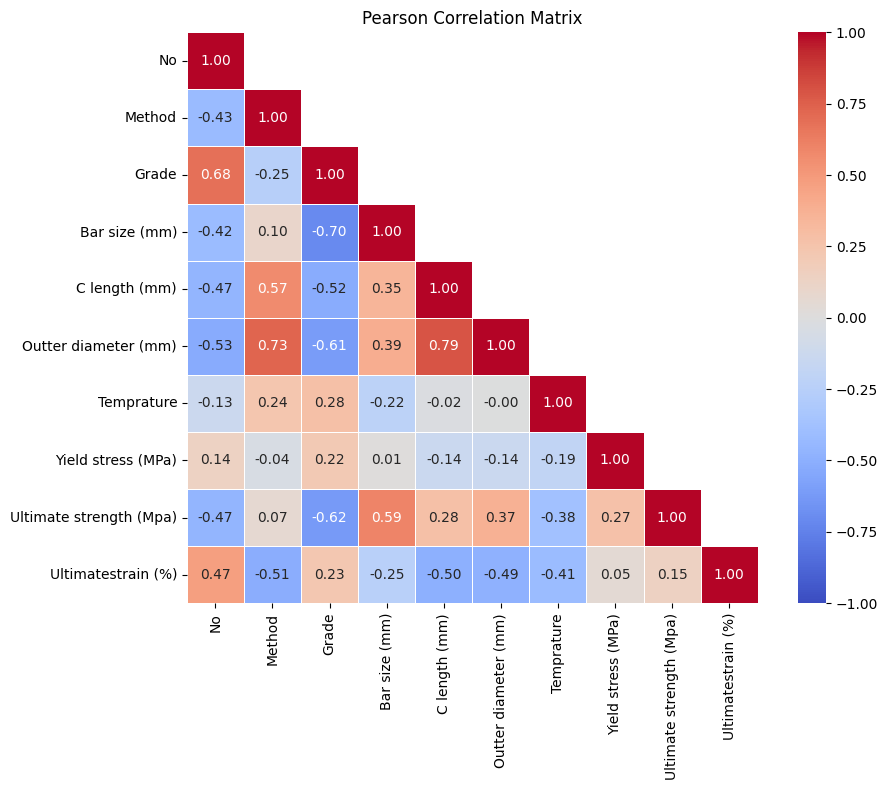

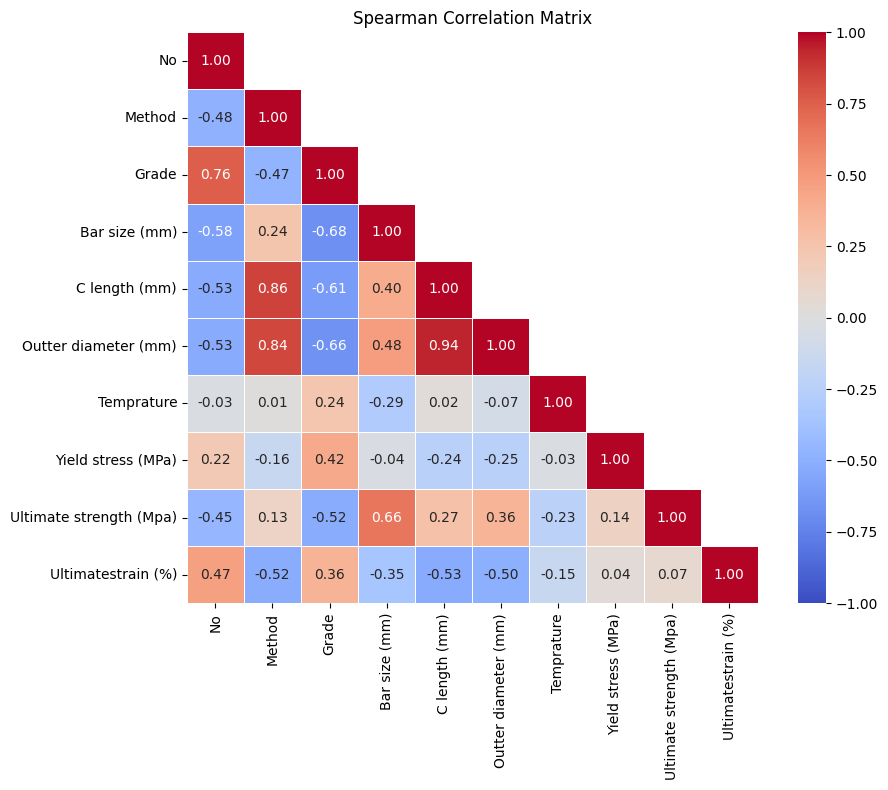

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# Select numeric columns
# ============================================================

df_num = df_clean.select_dtypes(include=np.number)

# ============================================================
# Pearson Correlation
# ============================================================

pearson_corr = df_num.corr(method='pearson')

mask = np.triu(
    np.ones_like(pearson_corr, dtype=bool),
    k=1  # keep diagonal, hide upper triangle
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# ============================================================
# Spearman Correlation
# ============================================================

spearman_corr = df_num.corr(method='spearman')

mask = np.triu(
    np.ones_like(spearman_corr, dtype=bool),
    k=1
)

plt.figure(figsize=(10,8))

sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

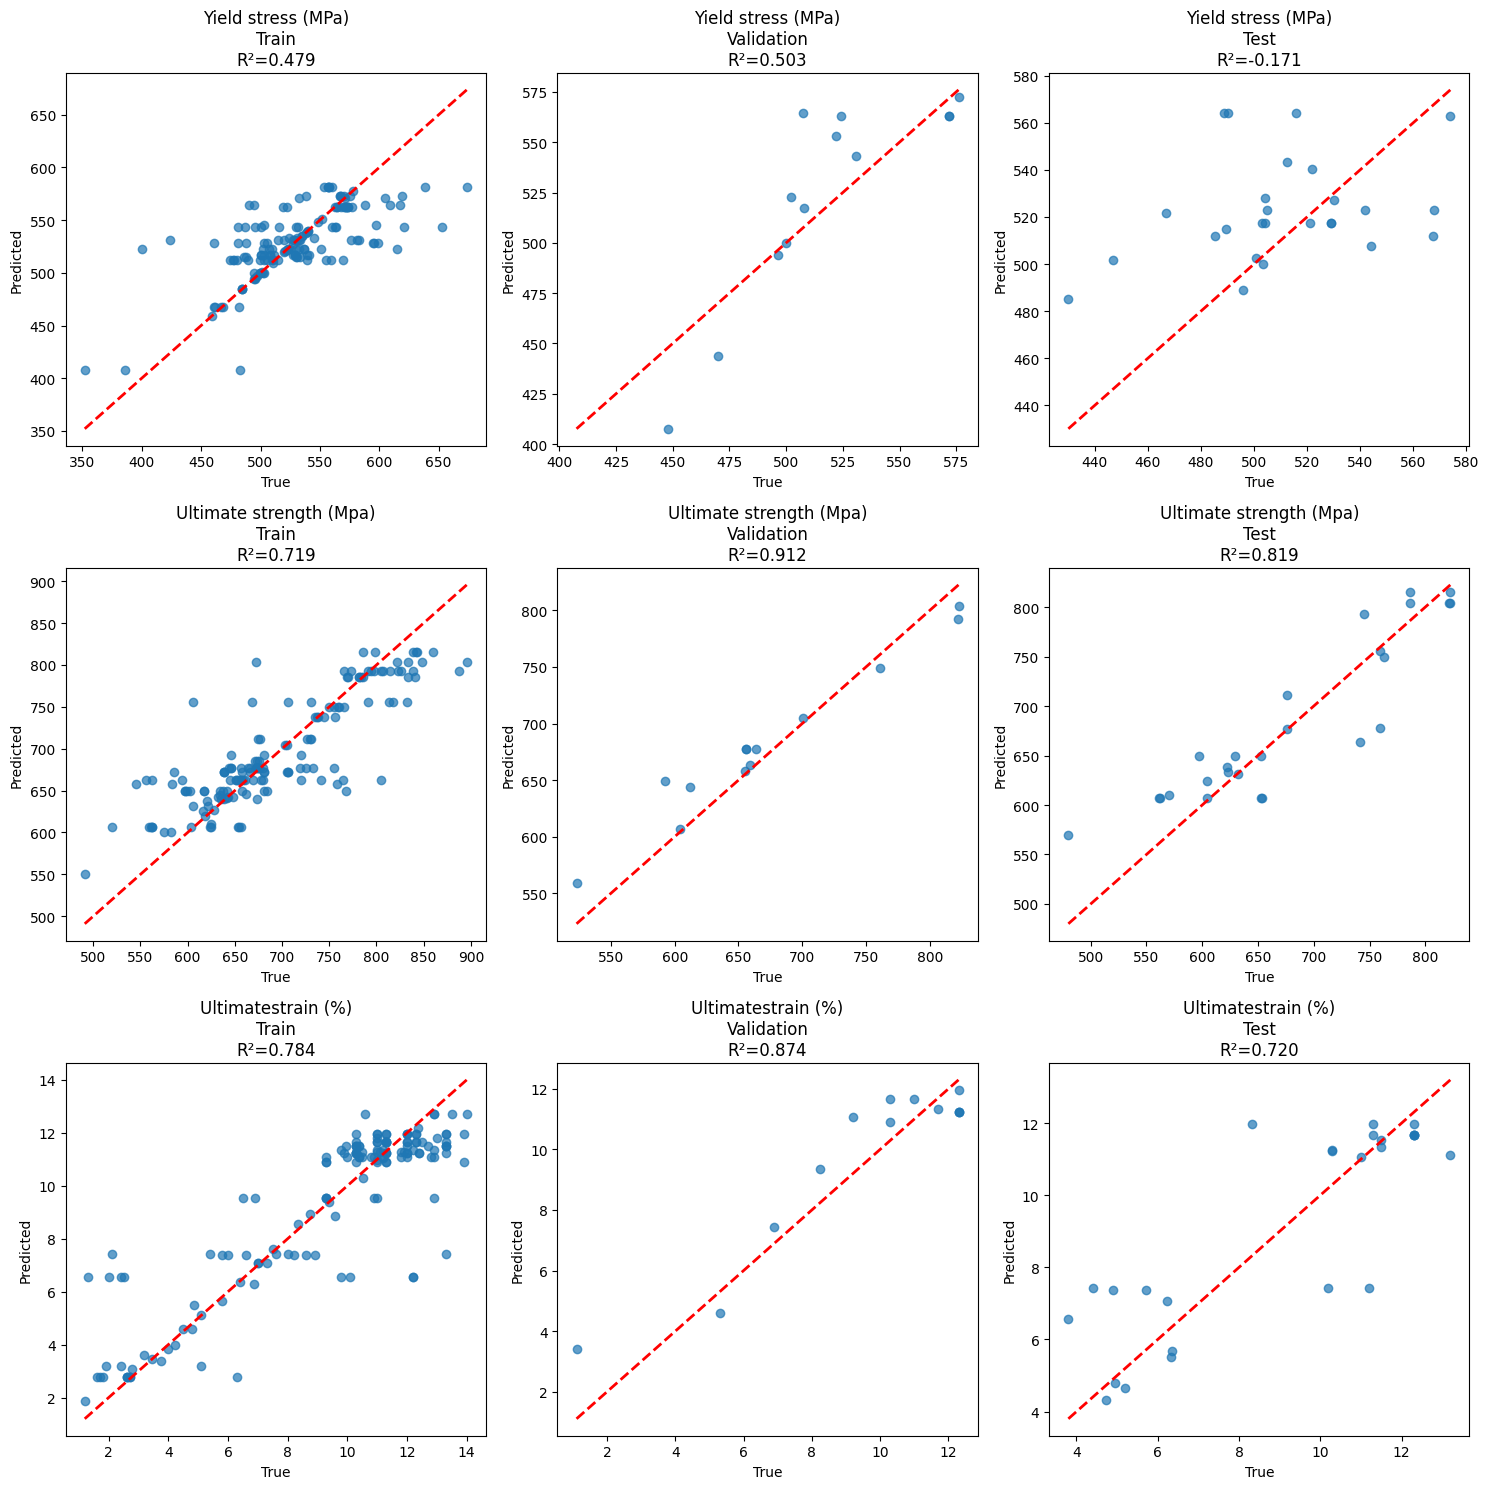


Performance Metrics
                    Target     Dataset        R2       RMSE          MSE
0       Yield stress (MPa)       Train  0.478711  33.731886  1137.840122
1       Yield stress (MPa)  Validation  0.502515  26.156097   684.141431
2       Yield stress (MPa)        Test -0.171092  36.103405  1303.455838
3  Ultimate strength (Mpa)       Train  0.718642  44.154813  1949.647503
4  Ultimate strength (Mpa)  Validation  0.912075  24.909353   620.475862
5  Ultimate strength (Mpa)        Test  0.818729  39.370506  1550.036764
6       Ultimatestrain (%)       Train  0.784375   1.620395     2.625679
7       Ultimatestrain (%)  Validation  0.873988   1.149589     1.321554
8       Ultimatestrain (%)        Test  0.719851   1.661654     2.761094


In [124]:
####### -----------------------------XGBoost------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# =============================================================================
# USER SETTINGS
# =============================================================================

# file_path = "/Users/hamed/Documents/Papers/6.StressStrainData/TensileDataSet.csv"

targets = [
    "Yield stress (MPa)",
    "Ultimate strength (Mpa)",
    "Ultimatestrain (%)"
]

# Features
feature_cols = [
    "Method",
    # "Grade",
    "Bar size (mm)",
    "C length (mm)",
    "Outter diameter (mm)",
    "Temprature"
]

# -----------------------------------------------------------------------------
# Hyperparameters for Yield Stress Model
# -----------------------------------------------------------------------------

params_fy = {
    "n_estimators": 5000,
    "max_depth": 5,
    "learning_rate": 0.05,
    "subsample": 0.8,         
    "colsample_bytree": 0.8,
    "random_state": 42#420
}

# -----------------------------------------------------------------------------
# Hyperparameters for Ultimate Strength Model
# -----------------------------------------------------------------------------

params_fu = {
    "n_estimators": 400,
    "max_depth": 3,
    "learning_rate": 0.01,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42
}

# -----------------------------------------------------------------------------
# Hyperparameters for Ultimate Strain Model
# -----------------------------------------------------------------------------

params_eps = {
    "n_estimators": 400,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42#40
}

# =============================================================================
# LOAD DATA
# =============================================================================

# df = pd.read_csv(file_path)
df = df_clean

X = df[feature_cols]

# One-hot encoding for categorical columns
X = pd.get_dummies(X, drop_first=True)

# =============================================================================
# TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X_train, X_temp = train_test_split(
    X,
    test_size=0.20,
    random_state=42
)

X_val, X_test = train_test_split(
    X_temp,
    test_size=0.65,
    random_state=42
)

# =============================================================================
# TRAINING LOOP
# =============================================================================

param_dict = {
    "Yield stress (MPa)": params_fy,
    "Ultimate strength (Mpa)": params_fu,
    "Ultimatestrain (%)": params_eps
}

results = []

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 15)
)

for row_idx, target in enumerate(targets):

    y = df[target]

    y_train = y.loc[X_train.index]
    y_val = y.loc[X_val.index]
    y_test = y.loc[X_test.index]

    model = XGBRegressor(**param_dict[target])

    model.fit(
        X_train,
        y_train
    )

    # -------------------------------------------------------------------------
    # Predictions
    # -------------------------------------------------------------------------

    pred_train = model.predict(X_train)
    pred_val = model.predict(X_val)
    pred_test = model.predict(X_test)

    datasets = [
        ("Train", y_train, pred_train),
        ("Validation", y_val, pred_val),
        ("Test", y_test, pred_test)
    ]

    # -------------------------------------------------------------------------
    # Metrics
    # -------------------------------------------------------------------------

    for col_idx, (name, y_true, y_pred) in enumerate(datasets):

        r2 = r2_score(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)

        results.append([
            target,
            name,
            r2,
            rmse,
            mse
        ])

        ax = axes[row_idx, col_idx]

        ax.scatter(
            y_true,
            y_pred,
            alpha=0.7
        )

        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            'r--',
            linewidth=2
        )

        ax.set_title(
            f"{target}\n{name}\nR²={r2:.3f}"
        )

        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# =============================================================================
# PERFORMANCE TABLE
# =============================================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Target",
        "Dataset",
        "R2",
        "RMSE",
        "MSE"
    ]
)

print("\nPerformance Metrics")
print(results_df)

# =============================================================================
# SAVE RESULTS
# =============================================================================

# results_df.to_csv(
#     "XGBoost_Performance.csv",
#     index=False
# )

# print("\nSaved: XGBoost_Performance.csv")

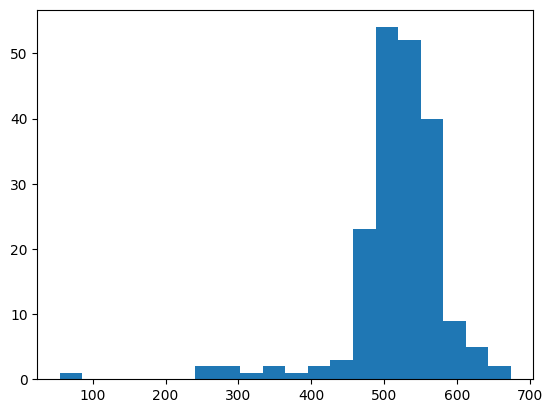

In [84]:
plt.hist(df["Yield stress (MPa)"], bins=20)
plt.show()

In [85]:
print(df["Yield stress (MPa)"].describe())

count    199.000000
mean     516.567121
std       68.737104
min       55.000000
25%      496.211263
50%      522.000000
75%      557.392933
max      673.617788
Name: Yield stress (MPa), dtype: float64


In [86]:
importance = model.feature_importances_

for feat, imp in sorted(
    zip(X.columns, importance),
    key=lambda x: x[1],
    reverse=True
):
    print(feat, imp)

C length (mm) 0.29057014
Outter diameter (mm) 0.23934144
Temprature 0.22986166
Bar size (mm) 0.096364744
Method 0.08185855
Grade 0.06200349


In [88]:
print(df["Grade"].unique())

[ 60  75 500 400 401 501 503]


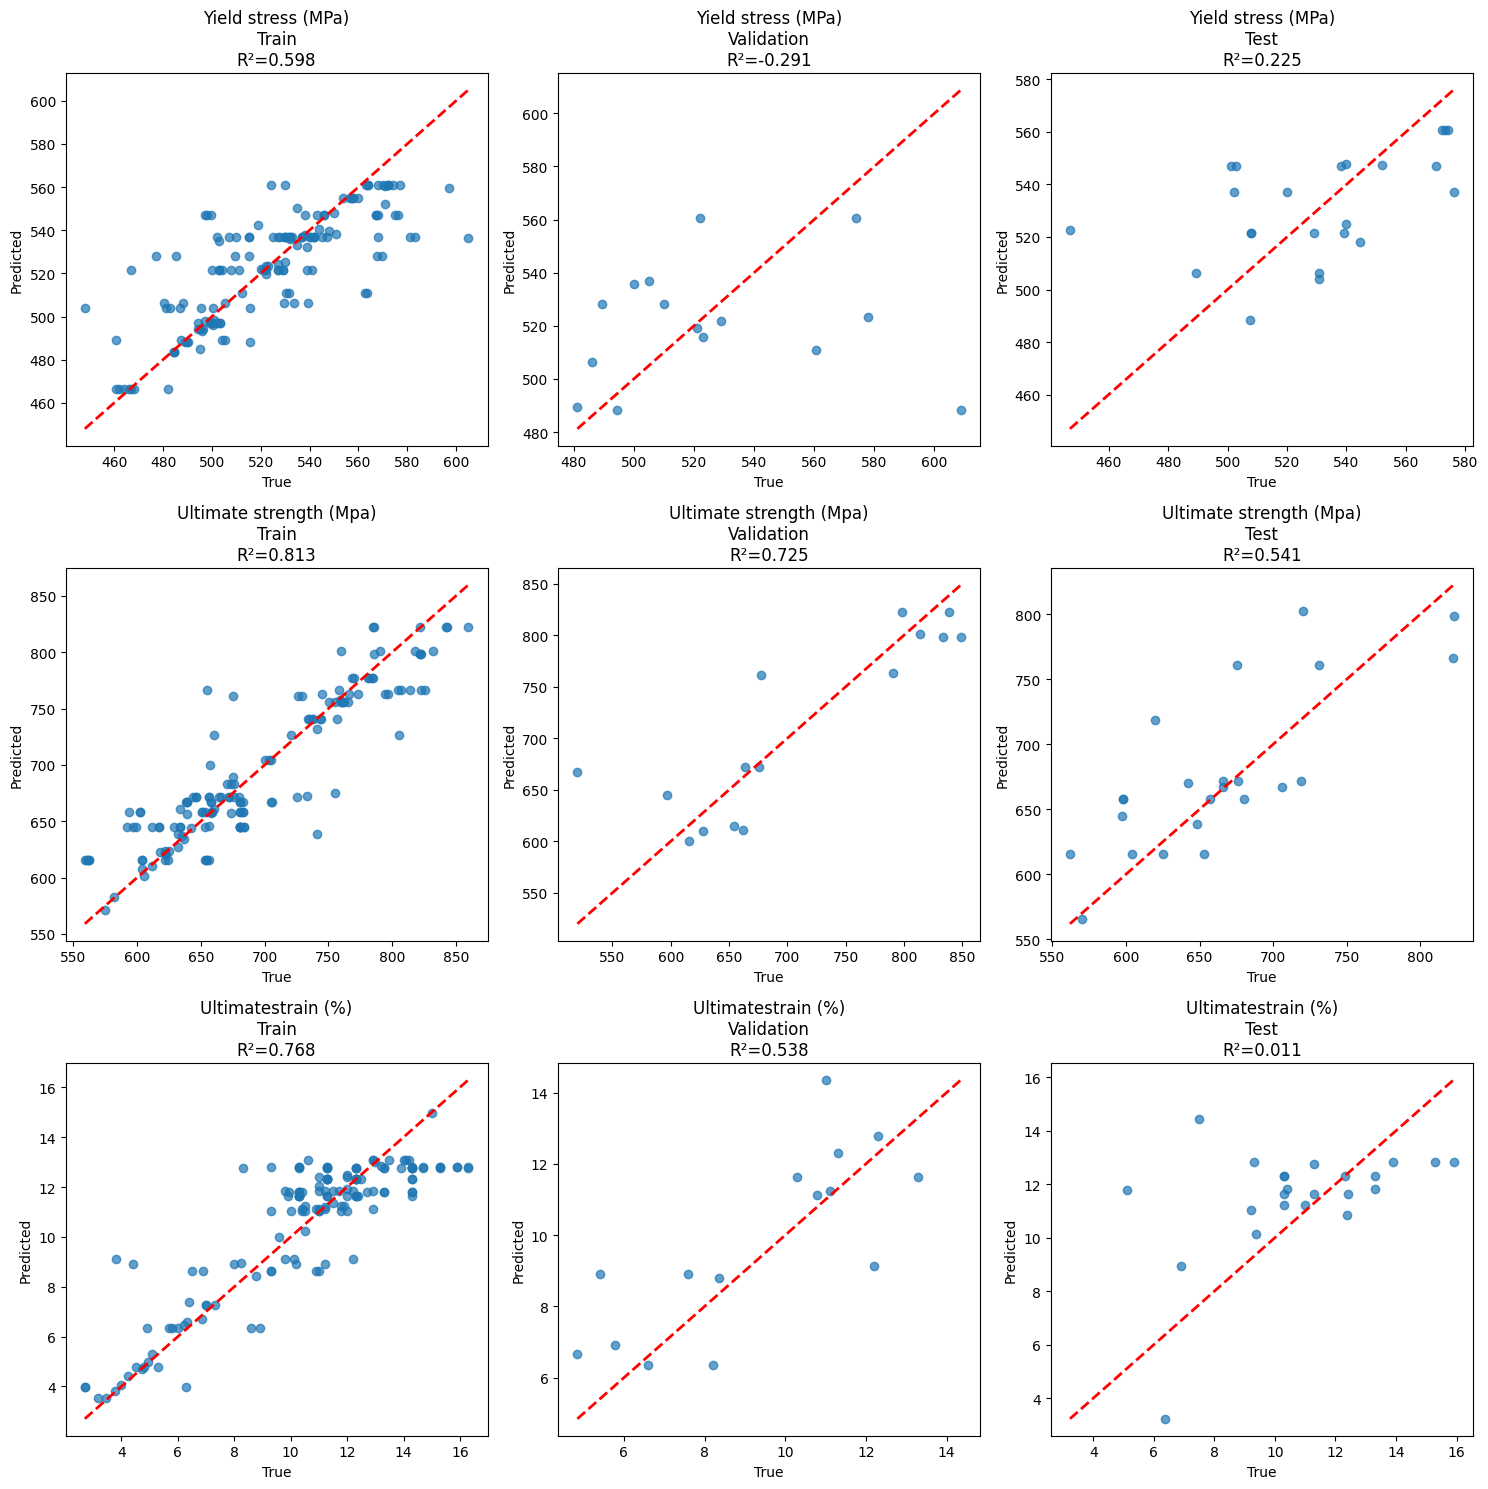


Performance Metrics
                    Target     Dataset        R2       RMSE          MSE
0       Yield stress (MPa)       Train  0.598442  20.407192   416.453522
1       Yield stress (MPa)  Validation -0.291109  41.911289  1756.556030
2       Yield stress (MPa)        Test  0.225242  27.693930   766.953735
3  Ultimate strength (Mpa)       Train  0.813367  31.448233   988.991333
4  Ultimate strength (Mpa)  Validation  0.724787  52.503239  2756.590088
5  Ultimate strength (Mpa)        Test  0.540904  45.441273  2064.909424
6       Ultimatestrain (%)       Train  0.768196   1.526053     2.328837
7       Ultimatestrain (%)  Validation  0.538412   1.809507     3.274317
8       Ultimatestrain (%)        Test  0.010912   2.643360     6.987352


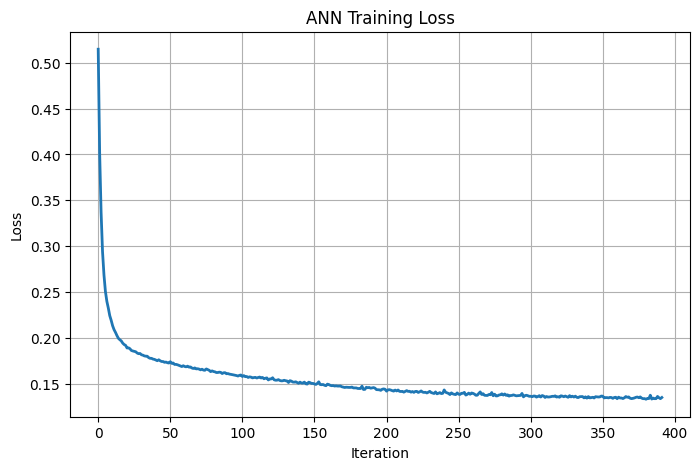

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    r2_score,
    mean_squared_error
)

# =============================================================================
# USER SETTINGS
# =============================================================================

file_path = "/Users/hamed/Documents/Papers/6.StressStrainData/TensileDataSet.csv"

feature_cols = [
    "Method",
    "Grade",
    "Bar size (mm)",
    "C length (mm)",
    "Outter diameter (mm)",
    "Temprature"
]

target_cols = [
    "Yield stress (MPa)",
    "Ultimate strength (Mpa)",
    "Ultimatestrain (%)"
]

# =============================================================================
# ANN HYPERPARAMETERS
# =============================================================================

hidden_layer_sizes = (64, 32)

activation = 'relu'
solver = 'adam'

learning_rate_init = 0.001

batch_size = 16

max_iter = 5000

alpha = 0.001      # L2 regularization

random_state = 42

# =============================================================================
# LOAD DATA
# =============================================================================

# df = pd.read_csv(file_path)
df = df_clean

X = df[feature_cols]
Y = df[target_cols]

# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Convert to numeric
X = X.astype(np.float32)
Y = Y.astype(np.float32)

# =============================================================================
# TRAIN / VALIDATION / TEST SPLIT
# =============================================================================

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=random_state
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.60,
    random_state=random_state
)

# =============================================================================
# SCALE INPUTS
# =============================================================================

x_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train)

X_val_scaled = x_scaler.transform(X_val)

X_test_scaled = x_scaler.transform(X_test)

# =============================================================================
# SCALE OUTPUTS
# =============================================================================

y_scaler = StandardScaler()

Y_train_scaled = y_scaler.fit_transform(Y_train)

Y_val_scaled = y_scaler.transform(Y_val)

Y_test_scaled = y_scaler.transform(Y_test)

# =============================================================================
# BUILD MODEL
# =============================================================================

model = MLPRegressor(
    hidden_layer_sizes=hidden_layer_sizes,
    activation=activation,
    solver=solver,
    learning_rate_init=learning_rate_init,
    batch_size=batch_size,
    max_iter=max_iter,
    alpha=alpha,
    random_state=random_state,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50
)

# =============================================================================
# TRAIN
# =============================================================================

model.fit(
    X_train_scaled,
    Y_train_scaled
)

# =============================================================================
# PREDICTIONS
# =============================================================================

pred_train_scaled = model.predict(X_train_scaled)
pred_val_scaled = model.predict(X_val_scaled)
pred_test_scaled = model.predict(X_test_scaled)

pred_train = y_scaler.inverse_transform(pred_train_scaled)
pred_val = y_scaler.inverse_transform(pred_val_scaled)
pred_test = y_scaler.inverse_transform(pred_test_scaled)

# =============================================================================
# RESULTS
# =============================================================================

results = []

fig, axes = plt.subplots(
    3,
    3,
    figsize=(15,15)
)

for i, target in enumerate(target_cols):

    datasets = [
        ("Train",
         Y_train.iloc[:, i].values,
         pred_train[:, i]),

        ("Validation",
         Y_val.iloc[:, i].values,
         pred_val[:, i]),

        ("Test",
         Y_test.iloc[:, i].values,
         pred_test[:, i])
    ]

    for j, (dataset_name,
            y_true,
            y_pred) in enumerate(datasets):

        r2 = r2_score(
            y_true,
            y_pred
        )

        mse = mean_squared_error(
            y_true,
            y_pred
        )

        rmse = np.sqrt(mse)

        results.append([
            target,
            dataset_name,
            r2,
            rmse,
            mse
        ])

        ax = axes[i, j]

        ax.scatter(
            y_true,
            y_pred,
            alpha=0.7
        )

        min_val = min(
            y_true.min(),
            y_pred.min()
        )

        max_val = max(
            y_true.max(),
            y_pred.max()
        )

        ax.plot(
            [min_val, max_val],
            [min_val, max_val],
            'r--',
            linewidth=2
        )

        ax.set_title(
            f"{target}\n{dataset_name}\nR²={r2:.3f}"
        )

        ax.set_xlabel("True")
        ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

# =============================================================================
# PERFORMANCE TABLE
# =============================================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Target",
        "Dataset",
        "R2",
        "RMSE",
        "MSE"
    ]
)

print("\nPerformance Metrics")
print(results_df)

results_df.to_csv(
    "ANN_Performance.csv",
    index=False
)

# =============================================================================
# LOSS CURVE
# =============================================================================

plt.figure(figsize=(8,5))

plt.plot(
    model.loss_curve_,
    linewidth=2
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("ANN Training Loss")
plt.grid(True)

plt.show()